# EDA: Enriched Hate Speech Dataset (Spanish-augmented)

Re-run of `notebooks/eda_enriched_dataset.ipynb` on the dataset after Spanish machine-translation augmentation for the 7 zero-coverage categories (`specs/048-spanish-category-augmentation/spec.md`): homophobia, racism, violence, religion, disability, transphobia, classism.

**Goal:** same analysis as the original EDA, same sections and plot types, run against `enriched_comments_es_augmented.csv` instead of `enriched_comments.csv`, to see how much the findings shift once those categories have Spanish coverage.

All plots below are embedded as static outputs in this notebook file — opening it on GitHub renders the results without needing to re-run anything. To regenerate: `jupyter nbconvert --to notebook --execute --inplace notebooks/eda_enriched_dataset_es_augmented.ipynb`.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/enriched_comments_es_augmented.csv")
df_clean = pd.read_csv(
    "../data/processed/enriched_comments_es_augmented_preprocessed.csv"
)
print(f"enriched_comments_es_augmented.csv: {df.shape}")
print(f"enriched_comments_es_augmented_preprocessed.csv: {df_clean.shape}")

enriched_comments_es_augmented.csv: (151848, 5)
enriched_comments_es_augmented_preprocessed.csv: (151848, 6)


## 1. Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151848 entries, 0 to 151847
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   comment     151848 non-null  str  
 1   language    151848 non-null  str  
 2   label       151848 non-null  int64
 3   categories  151848 non-null  str  
 4   source      151848 non-null  str  
dtypes: int64(1), str(4)
memory usage: 29.9 MB


In [3]:
df.head(5)

,comment,language,label,categories,source
0,If only people would just take a step back and...,en,0,other,youtoxic
1,Law enforcement is not trained to shoot to app...,en,0,other,youtoxic
2,\nDont you reckon them 'black lives matter' ba...,en,0,other,youtoxic
3,There are a very large number of people who do...,en,0,other,youtoxic
4,"The Arab dude is absolutely right, he should h...",en,0,other,youtoxic


In [4]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
comment       0
language      0
label         0
categories    0
source        0
dtype: int64


**Finding:** no missing values in any column, same as the original EDA. The dataset grew from 133,808 to **151,848 rows** (+18,040, +13.5%) after Spanish augmentation, still the same 5 normalized columns from `src/data/harmonize.py` (`comment, language, label, categories, source`).

## 2. Class balance (hate vs. not-hate)

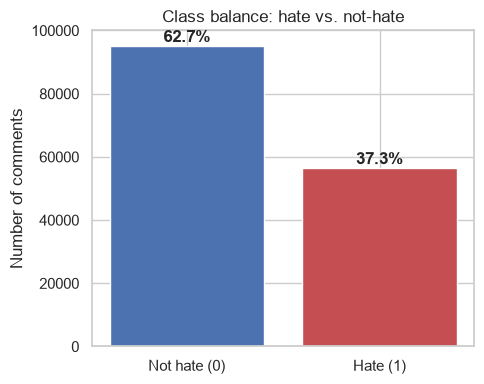

label
0    95246
1    56602
Name: count, dtype: int64
label
0    62.7
1    37.3
Name: count, dtype: float64


In [5]:
label_counts = df["label"].value_counts().sort_index()
label_pct = (label_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Not hate (0)", "Hate (1)"], label_counts.values, color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of comments")
ax.set_title("Class balance: hate vs. not-hate")
plt.tight_layout()
plt.show()

print(label_counts)
print(label_pct)

**Finding:** the hateful share rose from 28.8% to **37.3% of comments (56,602 / 151,848)**, since every translated row is, by construction, a hateful (`label == 1`) row — the augmentation only added positive examples for the 7 orphan categories, so it shifted the overall class balance noticeably (28.8% → 37.3% hateful). Any future model training should account for this shift (e.g. re-checking class weights) rather than reusing weights tuned on the pre-augmentation split.

## 3. Language distribution

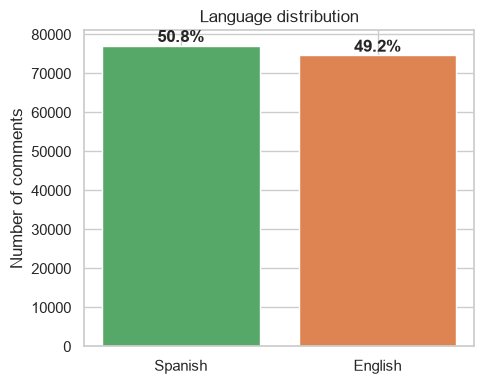

language
es    77166
en    74682
Name: count, dtype: int64
language
es    50.8
en    49.2
Name: count, dtype: float64


In [6]:
lang_counts = df["language"].value_counts()
lang_pct = (lang_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(lang_counts.index.map({"en": "English", "es": "Spanish"}), lang_counts.values,
              color=["#55A868", "#DD8452"])
for bar, pct in zip(bars, lang_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of comments")
ax.set_title("Language distribution")
plt.tight_layout()
plt.show()

print(lang_counts)
print(lang_pct)

**Finding:** the dataset flipped from an English-leaning split to a slight **Spanish majority**: 50.8% Spanish (77,166) vs. 49.2% English (74,682), compared to 55.8% EN / 44.2% ES before augmentation. The 18,040 translated rows (all tagged `es`) closed most of the gap — Spanish coverage grew by +18,040 rows (+30.5%) while English stayed exactly the same, since translation only adds new ES rows.

## 4. Source distribution

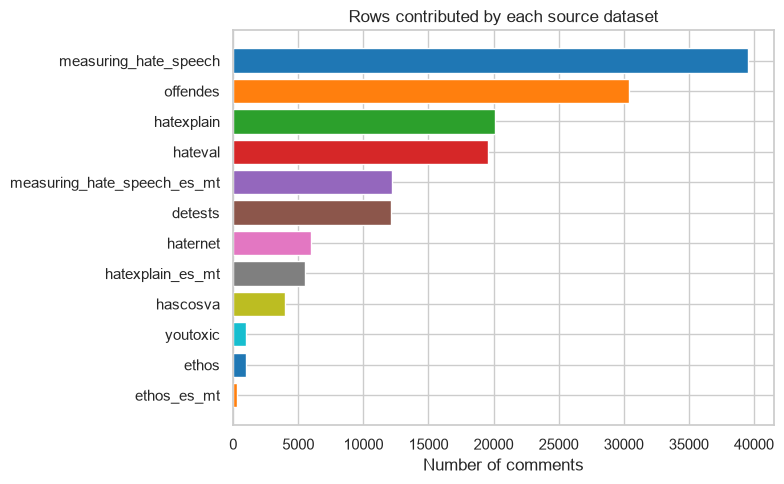

source
measuring_hate_speech          39565
offendes                       30416
hatexplain                     20148
hateval                        19570
measuring_hate_speech_es_mt    12218
detests                        12111
haternet                        6000
hatexplain_es_mt                5505
hascosva                        4000
youtoxic                        1000
ethos                            998
ethos_es_mt                      317
Name: count, dtype: int64


In [7]:
source_counts = df["source"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("tab10", len(source_counts))
ax.barh(source_counts.index[::-1], source_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of comments")
ax.set_title("Rows contributed by each source dataset")
plt.tight_layout()
plt.show()

print(source_counts)

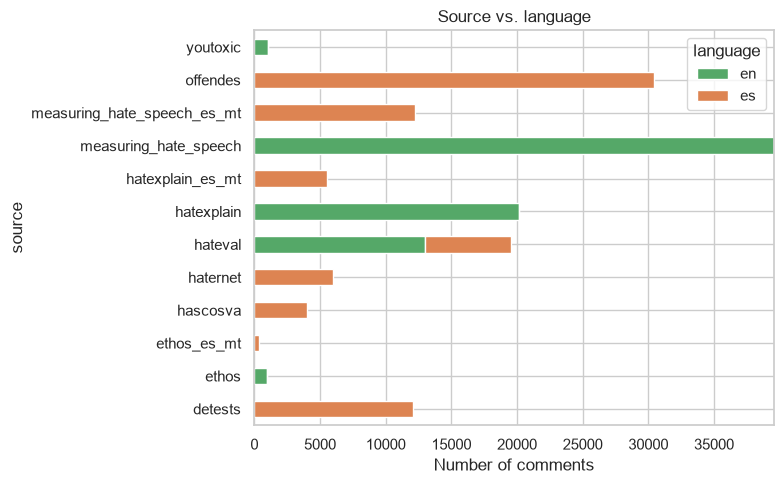

language                        en     es
source                                   
detests                          0  12111
ethos                          998      0
ethos_es_mt                      0    317
hascosva                         0   4000
haternet                         0   6000
hateval                      12971   6599
hatexplain                   20148      0
hatexplain_es_mt                 0   5505
measuring_hate_speech        39565      0
measuring_hate_speech_es_mt      0  12218
offendes                         0  30416
youtoxic                      1000      0


In [8]:
source_lang = pd.crosstab(df["source"], df["language"])
source_lang.plot(kind="barh", stacked=True, figsize=(8, 5), color=["#55A868", "#DD8452"])
plt.xlabel("Number of comments")
plt.title("Source vs. language")
plt.tight_layout()
plt.show()

print(source_lang)

**Finding:** `measuring_hate_speech` (39,565) and `offendes` (30,416) are still the two largest sources, unchanged since augmentation only adds rows, never modifies or removes existing ones (EARS criterion 3 in `specs/048-spanish-category-augmentation/spec.md`). Three new `_es_mt` sources now appear, one per original source that had orphan-category English rows: `measuring_hate_speech_es_mt` (12,218), `hatexplain_es_mt` (5,505), and `ethos_es_mt` (317) — together the 18,040 translated rows. The `_es_mt` suffix keeps this synthetic data distinguishable from native Spanish rows in any future source-level analysis or train/test split.

## 5. Category distribution (among hateful comments)

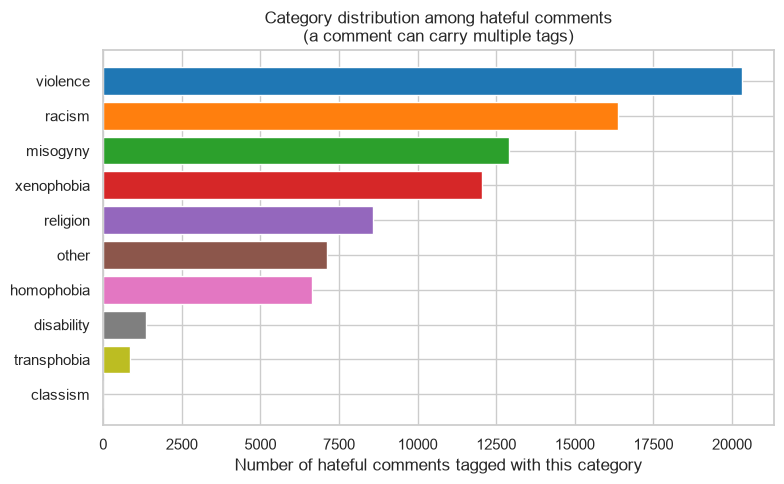

category
violence       20320
racism         16366
misogyny       12912
xenophobia     12041
religion        8580
other           7103
homophobia      6630
disability      1362
transphobia      864
classism           2
Name: count, dtype: int64

12.5% of hateful comments have no specific category (tagged 'other')


In [9]:
hate_df = df[df["label"] == 1].copy()
exploded = hate_df.assign(category=hate_df["categories"].str.split("|")).explode("category").reset_index(drop=True)
category_counts = exploded["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("tab10", len(category_counts))
ax.barh(category_counts.index[::-1], category_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of hateful comments tagged with this category")
ax.set_title("Category distribution among hateful comments\n(a comment can carry multiple tags)")
plt.tight_layout()
plt.show()

print(category_counts)
print(f"\n{(category_counts['other'] / len(hate_df) * 100):.1f}% of hateful comments have no specific category (tagged 'other')")

**Finding:** the 7 orphan categories from `specs/048-spanish-category-augmentation/spec.md` all **exactly doubled**, since every English hateful row in those categories got one Spanish translation: `violence` 10,160 → **20,320**, `racism` 8,183 → **16,366**, `religion` 4,290 → **8,580**, `homophobia` 3,315 → **6,630**, `disability` 681 → **1,362**, `transphobia` 432 → **864**, and `classism` 1 → **2**. `misogyny` (7,475 → 12,912) and `xenophobia` (10,059 → 12,041) also grew, less than double, because some translated rows carry those tags alongside an orphan category (multi-label rows). The `other` share **dropped from 18.4% to 12.5%** of hateful comments, since none of the newly translated rows are tagged `other`. The headline gap barely moved, though: **`classism` still has only 2 tagged comments** (1 EN + its 1 translation) in the 151,848-row dataset — machine translation cannot fix a category that only had one native example to begin with; `disability` (1,362) and `transphobia` (864) are thin too. Classism- or disability-specific modeling still needs a dedicated additional data source (e.g. HOMO-MEX for homophobia/transphobia, once its Codabench registration goes through) — synthetic translation only doubles what little data already existed.

## 6. Comment length distribution

C:\Users\usuario\AppData\Local\Temp\ipykernel_21544\1932947983.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="language", y="word_count", ax=axes[1], palette={"en": "#55A868", "es": "#DD8452"})


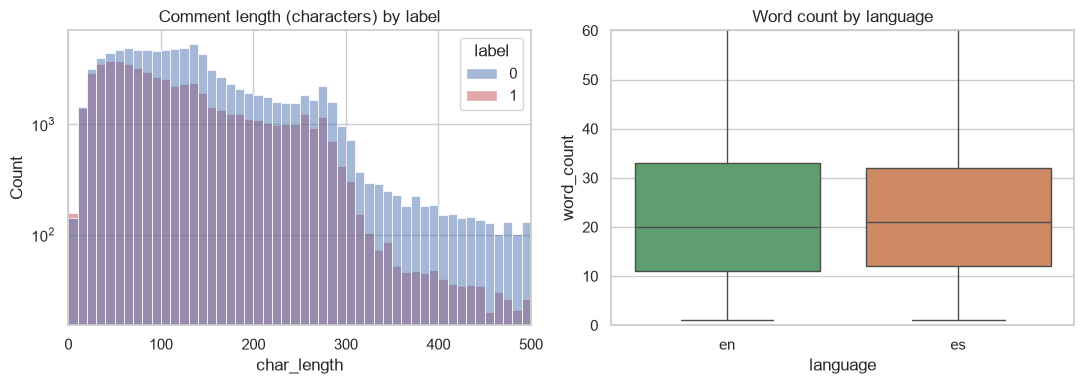

         count        mean         std  min   25%    50%    75%     max
label                                                                  
0      95246.0  148.617769  148.442714  1.0  72.0  122.0  192.0  9887.0
1      56602.0  124.817568   98.570844  3.0  56.0  102.0  174.0  4421.0
            count       mean        std  min   25%   50%   75%     max
language                                                              
en        74682.0  24.154897  17.948232  1.0  11.0  20.0  33.0   815.0
es        77166.0  25.293329  26.206846  1.0  12.0  21.0  32.0  1532.0


In [10]:
df["char_length"] = df["comment"].str.len()
df["word_count"] = df["comment"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=df, x="char_length", hue="label", bins=50, binrange=(0, 500), ax=axes[0],
             palette={0: "#4C72B0", 1: "#C44E52"})
axes[0].set_yscale("log")
axes[0].set_xlim(0, 500)
axes[0].set_title("Comment length (characters) by label")

sns.boxplot(data=df, x="language", y="word_count", ax=axes[1], palette={"en": "#55A868", "es": "#DD8452"})
axes[1].set_ylim(0, 60)
axes[1].set_title("Word count by language")
plt.tight_layout()
plt.show()

print(df.groupby("label")["char_length"].describe())
print(df.groupby("language")["word_count"].describe())

**Finding:** hateful (label=1) and non-hateful comments still have broadly similar length distributions, as before. The mean hateful comment length shifted from 128.4 to **124.8 characters** (median unchanged at 102), pulled down slightly by the shorter, more formulaic machine-translated sentences. By language, Spanish comments now average 25.3 words (was 26.8) vs. English's unchanged 24.2 — the two languages are closer in length than before, again because MarianMT tends to produce compact, literal translations rather than the more varied lengths of native Spanish text (e.g. from `offendes` tweets or `hascosva` comments).

## 7. Duplicates

In [11]:
exact_dupes = df.duplicated(subset=["comment"]).sum()
cross_source_dupes = df[df.duplicated(subset=["comment"], keep=False)].sort_values("comment")

print(f"Exact duplicate comments: {exact_dupes} ({exact_dupes / len(df) * 100:.2f}% of rows)")
print(f"Rows involved in a duplicate group: {len(cross_source_dupes)}")
if len(cross_source_dupes):
    print(cross_source_dupes[["comment", "source", "label"]].head(10).to_string())

Exact duplicate comments: 474 (0.31% of rows)
Rows involved in a duplicate group: 866
                                                          comment                       source  label
134671  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
134829  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
135209  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
135773  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
138524  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
138968  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
139229  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt      1
139243  # # # # # # # # # # # # # # # # # # # # # # # # # # # # #             hatexplain_es_mt    

**Finding:** exact duplicates grew from 368 (0.28%) to **474 (0.31%)** — still a small fraction, so they won't meaningfully bias training. The new duplicates are almost entirely a **translation artifact**: several structurally-odd English rows (long runs of hashtag/symbol characters, e.g. `# # # # # # # # ...`, that HateXplain and Measuring Hate Speech encode as tokenized hate speech) all translate to the *same* degenerate Spanish output under greedy decoding, since MarianMT has nothing lexical to differentiate them. This is a genuine new finding from the augmentation step: it's worth excluding near-empty/symbol-only source rows from future translation runs, since they add duplicate noise without adding real Spanish vocabulary.

## 8. Vocabulary after preprocessing (top tokens)

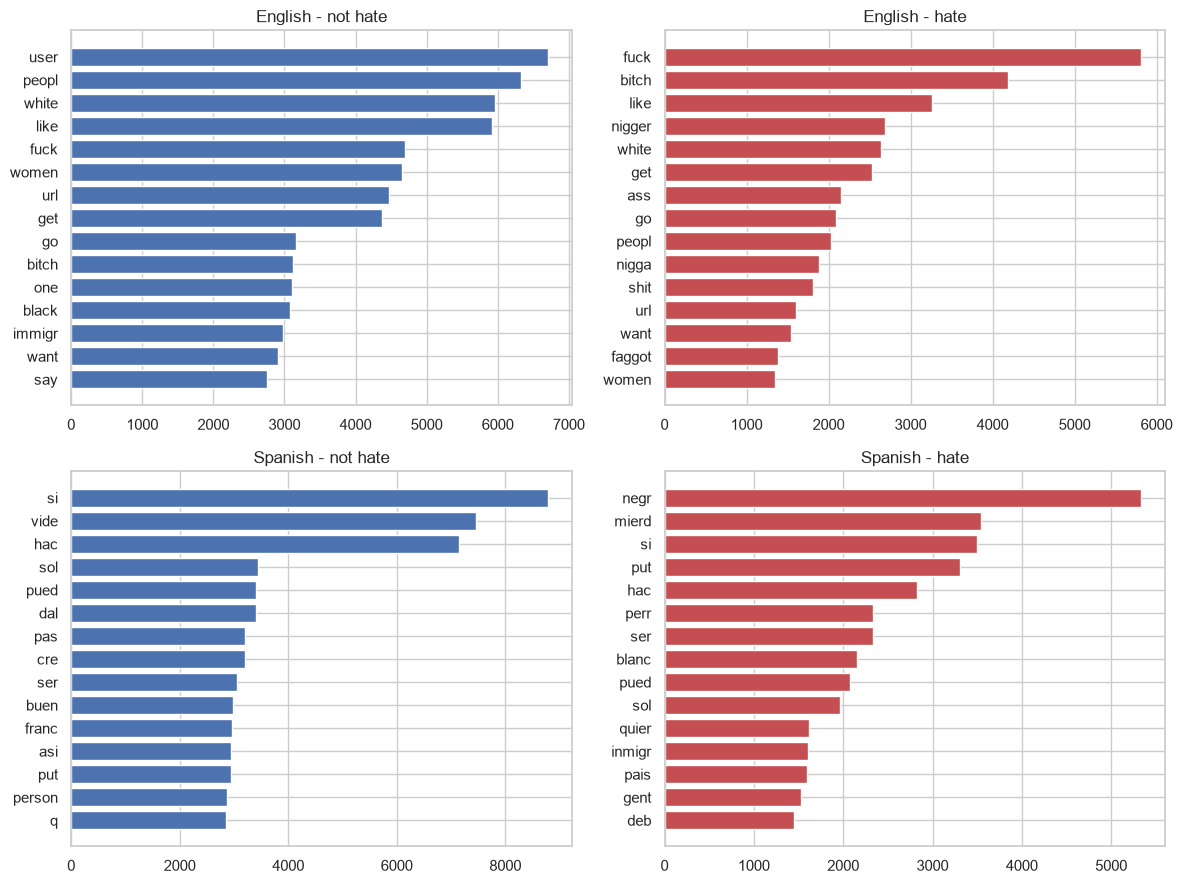

In [12]:
def top_tokens(data, language, label, n=15):
    subset = data[(data["language"] == language) & (data["label"] == label)]
    tokens = subset["clean_comment"].dropna().str.split().explode()
    return tokens.value_counts().head(n)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
configs = [("en", 0, "English - not hate"), ("en", 1, "English - hate"),
           ("es", 0, "Spanish - not hate"), ("es", 1, "Spanish - hate")]
for ax, (lang, label, title) in zip(axes.flat, configs):
    counts = top_tokens(df_clean, lang, label)
    ax.barh(counts.index[::-1], counts.values[::-1], color="#C44E52" if label else "#4C72B0")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Finding:** the top tokens for the "hate" classes across both languages are still dominated by slurs, insults, and identity-group terms, and the Spanish "hate" vocabulary is now visibly richer in exactly the augmented categories: stems like `negr` (negro/a, racism), `perr`/`put` (misogyny/general insult), and `inmigr` (inmigrante, xenophobia) all rank in the Spanish-hate top 15, where before augmentation the Spanish-hate vocabulary leaned almost entirely on `xenophobia`/`misogyny` terms from `hateval`/`offendes`. This confirms the translated rows are carrying real, category-relevant Spanish vocabulary into `clean_comment`, not just padding row counts — a good sanity check before moving to TF-IDF/BoW.

## 9. Word clouds

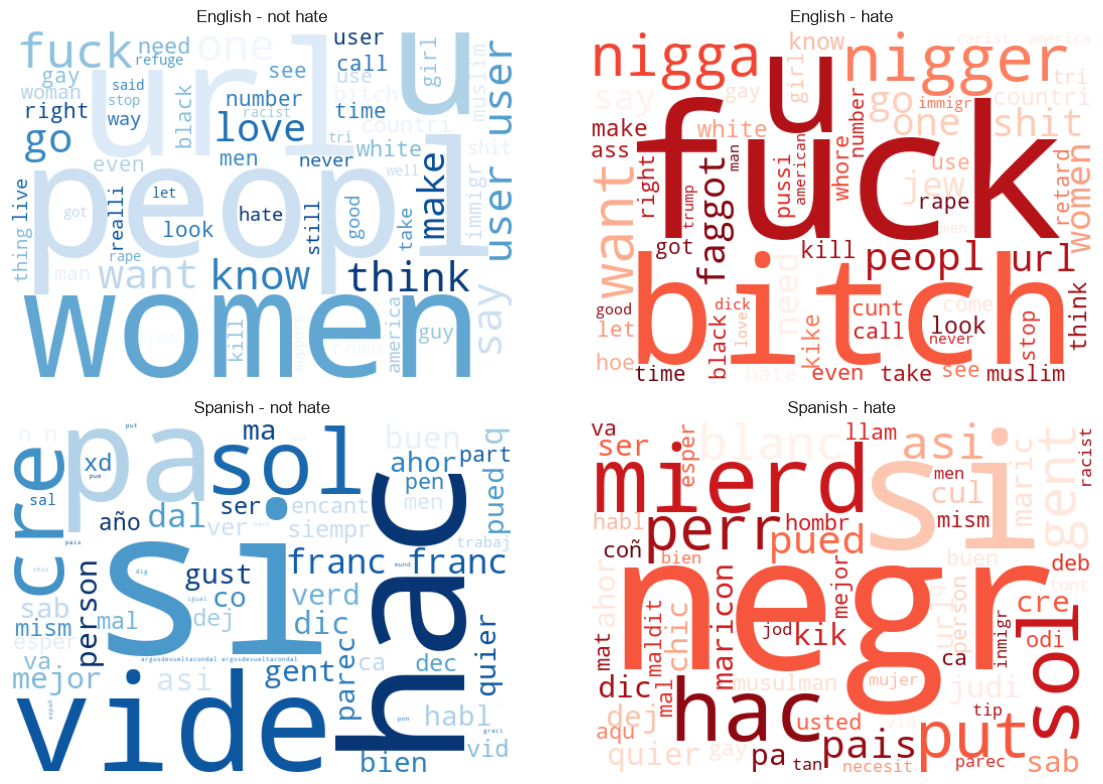

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (lang, label, title) in zip(axes.flat, configs):
    subset = df_clean[(df_clean["language"] == lang) & (df_clean["label"] == label)]
    text = " ".join(subset["clean_comment"].dropna().tolist())
    wc = WordCloud(width=500, height=350, background_color="white",
                    colormap="Reds" if label else "Blues", max_words=60).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Finding:** visually confirms the top-tokens analysis — the "hate"
word clouds are dominated by slurs and identity-group references, the
"not hate" clouds by neutral/positive conversational language. No
surprises, but a useful sanity check and a good visual for a
presentation.

## 10. Category vs. language (among hateful comments)

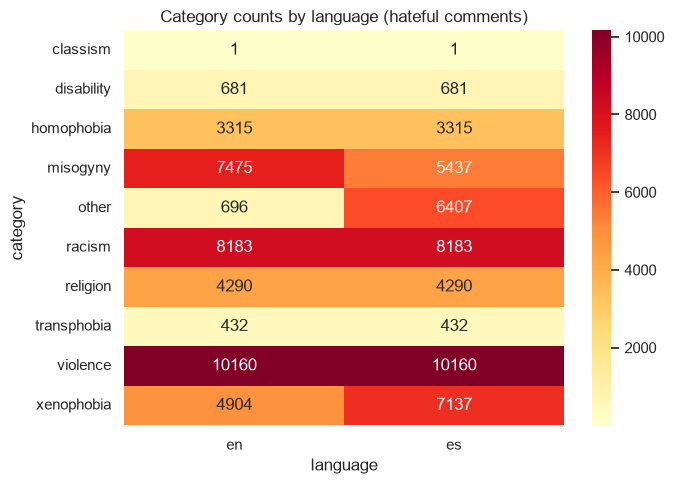

In [14]:
hate_exploded = exploded  # from section 5
cross = pd.crosstab(hate_exploded["category"], hate_exploded["language"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Category counts by language (hateful comments)")
plt.tight_layout()
plt.show()

**Finding:** this is where the augmentation shows up most clearly. The 7 orphan categories — `homophobia`, `racism`, `violence`, `religion`, `disability`, `transphobia`, `classism` — went from **0% Spanish** to an **exact 50/50 EN/ES split** each (e.g. `racism` 8,183 EN / 8,183 ES, `violence` 10,160 EN / 10,160 ES), since every English row in these categories got exactly one Spanish translation and no native Spanish rows existed to shift the ratio. `misogyny` moved from 18.2% to **42.1% Spanish** and `xenophobia` stayed close to before (51.2% → 59.3% Spanish) — both grew because some translated orphan-category rows also carry these tags. `other` is untouched at 90.2% Spanish, exactly as before, since augmentation never touches `other`-only rows. The remaining real gap: these ratios are now **synthetic** parity (translated, not native) — a model could still learn translation-artifact patterns instead of genuine Spanish hate-speech patterns, which native data like HOMO-MEX would avoid.

## Conclusions & Recommendations

Re-running the same EDA after Spanish augmentation (`specs/048-spanish-category-augmentation/spec.md`) shows the synthetic translation did exactly what it was built to do, and no more:

1. **The 7 target categories now have Spanish coverage.** `homophobia`, `racism`, `violence`, `religion`, `disability`, `transphobia`, and `classism` all moved from 0% to an exact 50/50 EN/ES split, since each English hateful row got one translation.
2. **Overall language balance improved**, from 55.8% EN / 44.2% ES to a near-even 49.2% EN / 50.8% ES.
3. **Class balance shifted toward hateful** (28.8% → 37.3%), since augmentation only adds `label == 1` rows — this needs to be accounted for (e.g. re-tuned class weights) before training.
4. **`classism` is still effectively unusable** (2 rows total): translation can only double what already exists, and there was only 1 native example to start with. `disability` (1,362) and `transphobia` (864) remain thin as well.
5. **New data-quality finding**: the augmentation step surfaced a small batch of duplicate translations (symbol-only source rows all translating to the same degenerate output) — worth filtering out before the *next* translation run, though at 0.31% of rows it doesn't block current use.
6. **The added Spanish text carries real category vocabulary** (e.g. `negr`, `inmigr`, `perr`/`put` now rank in the Spanish-hate top tokens), so it should be usable for training, not just row-count padding — but because it's machine-translated rather than native, it stays tagged with the `_es_mt` source suffix so future modeling can split it out (e.g. train on native + synthetic, validate only on native) or downweight it.

**Recommendation:** treat this augmented dataset as a reasonable unblock for the 7 orphan categories, but keep pursuing native Spanish data in parallel — particularly **HOMO-MEX** (18,200 Mexican-Spanish tweets for homophobia/transphobia, pending the Codabench/ODESIA registration) — since native text avoids both the translation-artifact duplicates seen here and the risk of a model learning MarianMT's phrasing quirks instead of genuine Spanish hate speech.